# Informe Teórico Práctico 2: Árboles de Decisión (Random Forest)

SI3015 Fundamentos de Aprendizaje Automático, Universidad EAFIT, 2026

**Integrantes:** Julián Lara, Matías Martínez y Luis Alfonso Agudelo

**Dataset:** películas y series de IMDb (`movies dataset.csv`)


En este notebook resolvemos el punto 1.3 del taller. En los casos 1 y 2 repetimos los mismos problemas de la regresión logística (predecir si un título tiene rating mayor o igual a 7), pero ahora con Random Forest, para comparar los dos modelos. En el caso 3 pasamos a un problema multiclase: clasificar el rating en baja, media o alta.

**Concepto: árbol de decisión.** Es un modelo que divide los datos con preguntas del tipo "¿la duración es menor a 60 minutos?". En cada nodo escoge la pregunta que deja los grupos más puros, y la pureza se mide con la **impureza de Gini**, $G = 1 - \sum_k p_k^2$, donde $p_k$ es la proporción de cada clase en el nodo. Un nodo con una sola clase tiene Gini 0. El problema de un árbol solo es que se aprende de memoria los datos de entrenamiento (sobreajuste).

**Concepto: Random Forest.** Entrena muchos árboles distintos y los pone a votar. Cada árbol se entrena con una muestra aleatoria con reemplazo de las filas (**bagging**) y en cada división solo mira un subconjunto aleatorio de columnas. Así los árboles se equivocan en cosas diferentes y, al promediar, los errores individuales se compensan. Lo usamos porque captura relaciones no lineales e interacciones entre variables sin que tengamos que definirlas, y como se basa en umbrales no necesita escalar los datos.

## 1. Carga del dataset

El archivo tiene 9999 filas y 9 columnas: título, año, género, rating, sinopsis, reparto, votos, duración y recaudo. Antes de modelar hay que revisar cómo vienen los datos porque casi todas las columnas están guardadas como texto.

In [1]:
# Librerias que usamos en todo el notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
SEMILLA = 42  # semilla fija para que los resultados se puedan repetir

In [2]:
# El csv esta en la raiz del repositorio, un nivel arriba de esta carpeta
df_raw = pd.read_csv("../movies dataset.csv")
print("Filas y columnas:", df_raw.shape)
df_raw.head()

Filas y columnas: (9999, 9)


,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN


In [3]:
# Tipo de dato y cantidad de faltantes de cada columna tal como viene el archivo
resumen = pd.DataFrame({
    "tipo": df_raw.dtypes.astype(str),
    "faltantes": df_raw.isna().sum(),
    "% faltantes": (df_raw.isna().mean() * 100).round(1),
})
resumen

,tipo,faltantes,% faltantes
MOVIES,str,0,0.0
YEAR,str,644,6.4
GENRE,str,80,0.8
RATING,float64,1820,18.2
ONE-LINE,str,0,0.0
STARS,str,0,0.0
VOTES,str,1820,18.2
RunTime,float64,2958,29.6
Gross,str,9539,95.4


In [4]:
# Asi se ve una fila por dentro: saltos de linea, espacios de relleno y varios datos en un mismo campo
for col in ["YEAR", "GENRE", "STARS", "VOTES", "Gross"]:
    print(f"{col:6}: {df_raw.loc[0, col]!r}")

YEAR  : '(2021)'
GENRE : '\nAction, Horror, Thriller            '
STARS : '\n    Director:\nPeter Thorwarth\n| \n    Stars:\nPeri Baumeister, \nCarl Anton Koch, \nAlexander Scheer, \nKais Setti\n'
VOTES : '21,062'
Gross : nan


## 2. Limpieza y transformación

Encontramos estos problemas en el archivo original:

1. Los campos de texto traen saltos de línea y espacios sobrantes.
2. `YEAR` mezcla el año con el tipo de producción, por ejemplo `(2021)`, `(2019– )` para una serie que sigue al aire, `(2005–2014)` para una serie terminada o `(2020 TV Special)`.
3. `VOTES` es texto con comas de miles y `Gross` es texto con el signo `$` y la letra `M`.
4. `STARS` junta director y actores en un solo campo.
5. Hay filas repetidas exactas.
6. Muchos títulos aparecen varias veces con distinto rating. Revisando, son episodios de una misma serie (por ejemplo `13 Reasons Why` aparece más de 30 veces).

La función de abajo resuelve todo eso y crea variables nuevas a partir del texto.

In [5]:
def limpiar_peliculas(df_raw):
    df = df_raw.copy()

    # Nombres cortos y en espanol para trabajar mas comodo
    df = df.rename(columns={
        "MOVIES": "titulo", "YEAR": "anio_texto", "GENRE": "genero", "RATING": "rating",
        "ONE-LINE": "sinopsis", "STARS": "reparto", "VOTES": "votos_texto",
        "RunTime": "duracion", "Gross": "recaudo_texto",
    })

    # Quitamos saltos de linea y espacios repetidos en los campos de texto
    for col in ["titulo", "anio_texto", "genero", "sinopsis", "reparto"]:
        df[col] = df[col].str.replace(r"\s+", " ", regex=True).str.strip()

    # Filas repetidas exactas
    n_antes = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    print("Filas duplicadas eliminadas:", n_antes - len(df))

    # Del texto del anio sacamos: anio de inicio, si es serie, si sigue al aire y el tipo
    anio = df["anio_texto"].fillna("")
    df["anio_inicio"] = pd.to_numeric(anio.str.extract(r"(\d{4})")[0])
    df["es_serie"] = anio.str.contains("–").astype(int)
    df["en_emision"] = anio.str.contains(r"–\s*\)").astype(int)
    df["tipo"] = np.select(
        [anio.str.contains("–"), anio.str.contains("TV Special"), anio.str.contains("TV Movie"),
         anio.str.contains("Video"), anio.str.contains("TV Short")],
        ["Serie", "Especial TV", "Pelicula TV", "Video", "Corto TV"],
        default="Pelicula",
    )

    # Votos y recaudo pasan de texto a numero
    df["votos"] = pd.to_numeric(df["votos_texto"].str.replace(",", ""), errors="coerce")
    df["recaudo_millones"] = pd.to_numeric(
        df["recaudo_texto"].str.replace(r"[$M]", "", regex=True), errors="coerce")

    # Del reparto sacamos si hay director registrado y cuantos actores aparecen
    df["tiene_director"] = df["reparto"].str.contains("Director").astype(int)
    actores = df["reparto"].str.extract(r"Stars?:(.*)")[0].fillna("")
    df["n_actores"] = actores.apply(lambda s: len([a for a in s.split(",") if a.strip()]))

    # Cantidad de generos que tiene cada titulo
    df["n_generos"] = df["genero"].fillna("").apply(
        lambda s: len([g for g in s.split(",") if g.strip()]))

    # "Add a Plot" significa que IMDb no tiene sinopsis, lo marcamos aparte
    df["sin_sinopsis"] = (df["sinopsis"] == "Add a Plot").astype(int)
    df["largo_sinopsis"] = np.where(df["sin_sinopsis"] == 1, 0, df["sinopsis"].str.split().str.len())

    # Un titulo repetido corresponde a episodios de una misma serie
    conteo = df["titulo"].value_counts()
    df["es_episodio"] = (df["titulo"].map(conteo) > 1).astype(int)

    return df


df = limpiar_peliculas(df_raw)
df[["titulo", "anio_inicio", "tipo", "es_serie", "en_emision", "rating", "votos",
    "duracion", "tiene_director", "n_actores", "n_generos", "es_episodio"]].head(8)

Filas duplicadas eliminadas: 431


,titulo,anio_inicio,tipo,es_serie,en_emision,rating,votos,duracion,tiene_director,n_actores,n_generos,es_episodio
0,Blood Red Sky,2021.0,Pelicula,0,0,6.1,21062.0,121.0,1,4,3,0
1,Masters of the Universe: Revelation,2021.0,Serie,1,1,5.0,17870.0,25.0,0,4,3,1
2,The Walking Dead,2010.0,Serie,1,0,8.2,885805.0,44.0,0,4,3,0
3,Rick and Morty,2013.0,Serie,1,1,9.2,414849.0,23.0,0,4,3,1
4,Army of Thieves,2021.0,Pelicula,0,0,NaN,NaN,NaN,1,4,3,0
5,Outer Banks,2020.0,Serie,1,1,7.6,25858.0,50.0,0,4,3,1
6,The Last Letter from Your Lover,2021.0,Pelicula,0,0,6.8,5283.0,110.0,1,4,2,0
7,Dexter,2006.0,Serie,1,0,8.6,665387.0,53.0,0,4,3,1


In [6]:
# Faltantes despues de la limpieza en las columnas que nos interesan
cols = ["rating", "votos", "duracion", "anio_inicio", "genero", "recaudo_millones"]
(df[cols].isna().mean() * 100).round(1).to_frame("% faltantes")

,% faltantes
rating,14.6
votos,14.6
duracion,26.8
anio_inicio,6.6
genero,0.8
recaudo_millones,95.2


Con esos porcentajes tomamos varias decisiones:

1. **Recaudo:** le falta cerca del 95 % de los datos. Imputar tanto sería inventar la columna, así que no la usamos.
2. **Rating:** es la variable objetivo, y sin ella la fila no sirve para entrenar. Esas filas se eliminan. Casi siempre son títulos que todavía no se estrenan, porque tampoco tienen votos.
3. **Duración:** entre las filas que sí tienen rating le falta alrededor del 17 %. La llenamos con la mediana de su tipo, porque un episodio de serie dura mucho menos que una película y una mediana general mezclaría las dos cosas. También guardamos una columna que indica que el dato era faltante.
4. **Votos:** van desde 5 hasta casi dos millones y la distribución es muy asimétrica. Aplicamos `log(1 + votos)` para comprimir la escala.
5. **Género y tipo:** son categóricas, así que las pasamos a columnas 0/1 (one hot). Un título puede tener varios géneros a la vez.

Para Random Forest el logaritmo de los votos no cambia nada, porque un árbol solo compara contra umbrales y el orden de los valores es el mismo. Lo dejamos para usar exactamente las mismas variables que en regresión logística.

In [7]:
def preparar_para_modelos(df):
    # Sin rating no hay objetivo, esas filas no sirven para entrenar
    d = df.dropna(subset=["rating"]).copy()

    # Duracion faltante: mediana de su mismo tipo y una bandera que indica que faltaba
    d["duracion_faltante"] = d["duracion"].isna().astype(int)
    d["duracion"] = d["duracion"].fillna(d.groupby("tipo")["duracion"].transform("median"))
    d["duracion"] = d["duracion"].fillna(d["duracion"].median())
    d["anio_inicio"] = d["anio_inicio"].fillna(d["anio_inicio"].median())

    # Logaritmo de los votos para reducir la asimetria
    d["log_votos"] = np.log1p(d["votos"])

    # Generos en formato one hot, una columna por genero
    generos = d["genero"].fillna("").str.get_dummies(sep=", ")
    generos.columns = ["gen_" + c.replace("-", "_") for c in generos.columns]

    # Tipo en one hot. Serie ya esta en es_serie y Pelicula queda como categoria base
    tipos = pd.get_dummies(d["tipo"], prefix="tipo", dtype=int)
    tipos.columns = [c.replace(" ", "_") for c in tipos.columns]
    tipos = tipos.drop(columns=["tipo_Serie", "tipo_Pelicula"])

    d = pd.concat([d, generos, tipos], axis=1).reset_index(drop=True)
    return d, list(generos.columns), list(tipos.columns)


d, cols_generos, cols_tipos = preparar_para_modelos(df)
print("Filas disponibles para modelar:", d.shape[0])
print("Columnas de genero:", len(cols_generos), "| columnas de tipo:", cols_tipos)

Filas disponibles para modelar: 8168
Columnas de genero: 27 | columnas de tipo: ['tipo_Corto_TV', 'tipo_Especial_TV', 'tipo_Pelicula_TV', 'tipo_Video']


### Variables objetivo

Para los casos 1 y 2 usamos `buena`, igual que en regresión logística: vale 1 si el rating es mayor o igual a 7.

Para el caso 3 creamos `categoria` con tres clases, usando cortes cercanos a los terciles del rating para que las clases queden de tamaño parecido:

1. **Baja:** rating menor a 6.5.
2. **Media:** rating desde 6.5 y menor a 7.5.
3. **Alta:** rating desde 7.5.

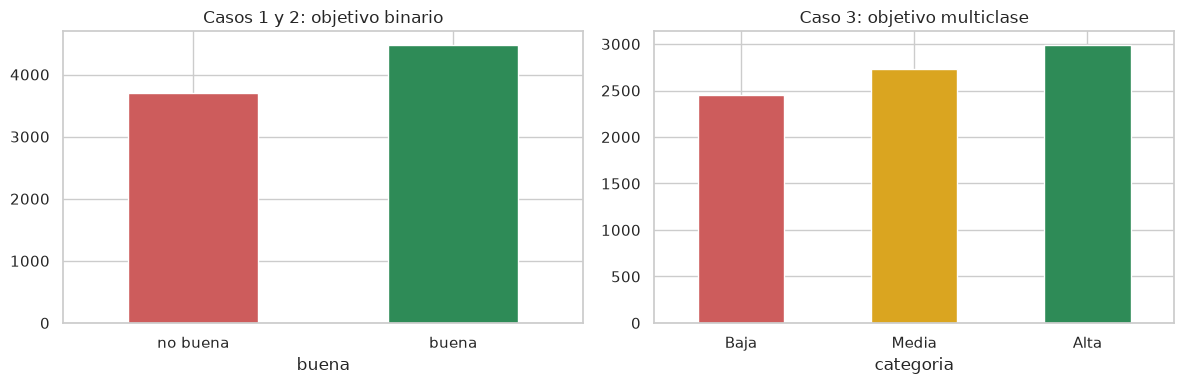

categoria
Alta     0.366
Media    0.334
Baja     0.300
Name: proportion, dtype: float64


In [8]:
# Objetivo binario para los casos 1 y 2
d["buena"] = (d["rating"] >= 7).astype(int)

# Objetivo multiclase para el caso 3
d["categoria"] = pd.cut(d["rating"], bins=[0, 6.5, 7.5, 10.01], labels=["Baja", "Media", "Alta"], right=False)

fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
d["buena"].value_counts().sort_index().plot(kind="bar", ax=ejes[0], color=["indianred", "seagreen"], rot=0)
ejes[0].set_xticklabels(["no buena", "buena"])
ejes[0].set_title("Casos 1 y 2: objetivo binario")
d["categoria"].value_counts().reindex(["Baja", "Media", "Alta"]).plot(
    kind="bar", ax=ejes[1], color=["indianred", "goldenrod", "seagreen"], rot=0)
ejes[1].set_title("Caso 3: objetivo multiclase")
plt.tight_layout()
plt.show()
print(d["categoria"].value_counts(normalize=True).round(3))

## 3. Análisis exploratorio

Revisamos cómo se comportan las variables principales en cada una de las tres categorías de rating, que es el problema nuevo de este notebook. El análisis del objetivo binario está en el notebook de regresión logística.

In [9]:
def resumen_iqr(serie):
    # Rango intercuartilico, limites de outliers e IQR ratio como se vio en clase
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return pd.Series({
        "Q1": q1, "Q3": q3, "IQR": iqr, "lim_inf": lim_inf, "lim_sup": lim_sup,
        "outliers": int(((serie < lim_inf) | (serie > lim_sup)).sum()),
        "IQR_ratio": iqr / (serie.max() - serie.min()),
    })


num = ["rating", "duracion", "votos", "log_votos", "anio_inicio", "n_actores", "n_generos", "largo_sinopsis"]
d[num].apply(resumen_iqr).T.round(3)

,Q1,Q3,IQR,lim_inf,lim_sup,outliers,IQR_ratio
rating,6.200,7.800,1.600,3.800,10.200,165.0,0.182
duracion,38.000,94.000,56.000,-46.000,178.000,116.0,0.066
votos,167.000,3780.750,3613.750,-5253.625,9201.375,1298.0,0.002
log_votos,5.124,8.238,3.114,0.453,12.909,43.0,0.248
anio_inicio,2015.000,2020.000,5.000,2007.500,2027.500,681.0,0.056
n_actores,4.000,4.000,0.000,4.000,4.000,952.0,0.000
n_generos,1.000,3.000,2.000,-2.000,6.000,0.0,0.667
largo_sinopsis,20.000,32.000,12.000,2.000,50.000,377.0,0.167


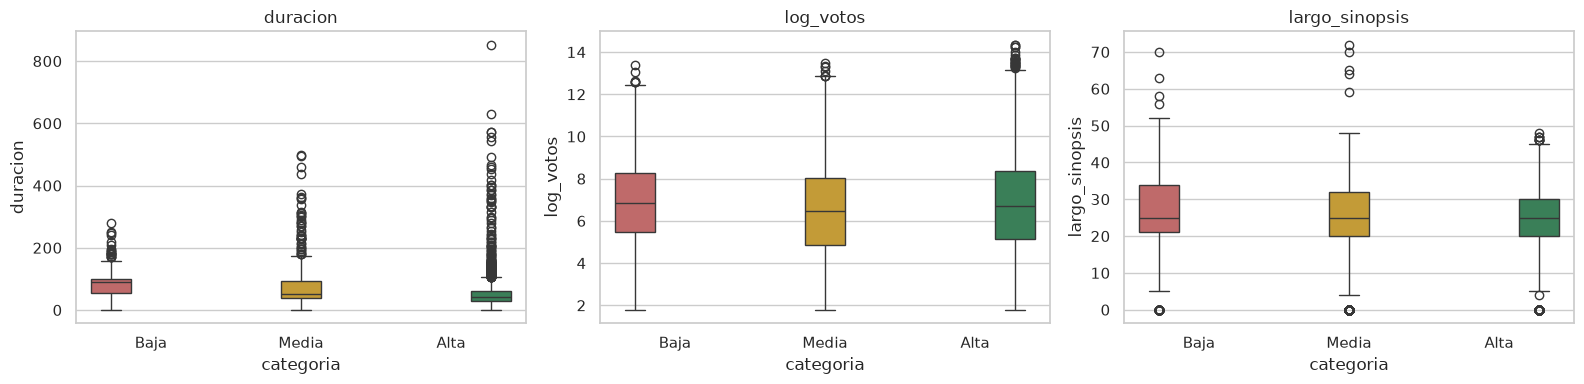

In [10]:
# Variables numericas segun la categoria de rating
fig, ejes = plt.subplots(1, 3, figsize=(16, 4))
for eje, col in zip(ejes, ["duracion", "log_votos", "largo_sinopsis"]):
    sns.boxplot(data=d, x="categoria", y=col, ax=eje, hue="categoria",
                palette=["indianred", "goldenrod", "seagreen"], legend=False)
    eje.set_title(col)
plt.tight_layout()
plt.show()

In [11]:
# Composicion de cada categoria segun tipo de titulo
pd.crosstab(d["tipo"], d["categoria"], normalize="index").mul(100).round(1)

categoria,Baja,Media,Alta
tipo,,,
Corto TV,14.3,42.9,42.9
Especial TV,36.6,44.6,18.8
Pelicula,44.7,32.7,22.6
Pelicula TV,48.6,37.0,14.4
Serie,13.8,33.0,53.2
Video,44.0,28.6,27.4


Lo que sacamos del análisis exploratorio para el problema multiclase:

1. Las tres clases quedaron balanceadas: 30.0 % baja, 33.4 % media y 36.6 % alta. Un modelo que diga siempre "Alta" acertaría el 36.6 %, así que ese es el mínimo a superar.
2. La duración baja a medida que sube la categoría: la mediana es 89 minutos en baja, 51 en media y 42 en alta.
3. Los votos no siguen un orden. La clase media es la que tiene menos votos y las clases baja y alta tienen más. Una relación así no la puede aprender un modelo lineal, pero un árbol sí.
4. `largo_sinopsis` tiene exactamente la misma mediana (25 palabras) en las tres clases. Desde ya parece una variable que no aporta.
5. El tipo de título cambia mucho la distribución. El 53.2 % de las series está en categoría alta y solo el 13.8 % en baja. En las películas pasa lo contrario: el 44.7 % está en baja.

### División entrenamiento y prueba

**Concepto.** Separar los datos en entrenamiento y prueba sirve para medir el modelo con datos que nunca vio. Si se evalúa con los mismos datos del entrenamiento, las métricas salen infladas.

Aquí hay un detalle propio de este dataset: los episodios de una misma serie tienen el mismo título, una duración parecida y votos parecidos. Con una división aleatoria normal, unos episodios caen en entrenamiento y otros en prueba, y el modelo termina reconociendo la serie en vez de aprender algo general. Por eso usamos `GroupShuffleSplit` agrupando por título: todos los episodios de una serie quedan del mismo lado. Dejamos el 80 % para entrenar y el 20 % para probar.

In [12]:
# Division 80/20 agrupando por titulo para que una serie no quede repartida en ambos conjuntos
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEMILLA)
idx_train, idx_test = next(gss.split(d, groups=d["titulo"]))
train, test = d.iloc[idx_train].copy(), d.iloc[idx_test].copy()

print("Entrenamiento:", train.shape[0], "filas")
print("Prueba:", test.shape[0], "filas")
print("Titulos compartidos entre ambos:", len(set(train["titulo"]) & set(test["titulo"])))

Entrenamiento: 6447 filas
Prueba: 1721 filas
Titulos compartidos entre ambos: 0


### Métricas y control del sobreajuste

Usamos las mismas métricas de clasificación del notebook de regresión logística: matriz de confusión, accuracy, precision, recall y F1. En el caso multiclase, precision, recall y F1 se calculan por clase y se promedian con **macro average**, es decir, cada clase pesa igual sin importar cuántas filas tenga.

**Concepto: sobreajuste (overfitting).** Pasa cuando el modelo aprende detalles y ruido del entrenamiento que no se repiten en datos nuevos. Se nota porque la métrica de entrenamiento sale muy por encima de la de prueba. En Random Forest se controla limitando cuánto crece cada árbol. Nosotros usamos `min_samples_leaf`, el mínimo de filas que debe tener cada hoja: con valores altos las hojas no pueden quedar con uno o dos títulos memorizados.

Para escoger `min_samples_leaf` no usamos el conjunto de prueba (eso sería hacer trampa). Hacemos **validación cruzada** de 5 particiones dentro del entrenamiento, también agrupando por título, y elegimos el valor con mejor F1 promedio.

In [13]:
N_ARBOLES = 300
grupos_train = train["titulo"]
cv = GroupKFold(n_splits=5)


def crear_rf(hoja=1):
    return RandomForestClassifier(n_estimators=N_ARBOLES, min_samples_leaf=hoja, random_state=SEMILLA, n_jobs=-1)


def elegir_hoja(columnas, objetivo, scoring, opciones=(1, 5, 10, 20, 40)):
    # Validacion cruzada agrupada dentro del entrenamiento para escoger min_samples_leaf
    puntajes = {}
    for hoja in opciones:
        puntajes[hoja] = cross_val_score(crear_rf(hoja), train[columnas], train[objetivo],
                                         groups=grupos_train, cv=cv, scoring=scoring).mean()
    mejor = max(puntajes, key=puntajes.get)
    print("F1 promedio en validacion cruzada por min_samples_leaf:",
          {k: round(float(v), 4) for k, v in puntajes.items()}, "| elegido:", mejor)
    return mejor


def evaluar(modelo, columnas, objetivo, nombre, etiquetas, mostrar=True):
    # Entrena, predice y calcula las metricas en entrenamiento y prueba
    modelo.fit(train[columnas], train[objetivo])
    pred = modelo.predict(test[columnas])
    pred_train = modelo.predict(train[columnas])
    binario = len(etiquetas) == 2
    promedio = "binary" if binario else "macro"
    metricas = {
        "modelo": nombre,
        "n_variables": len(columnas),
        "accuracy_train": accuracy_score(train[objetivo], pred_train),
        "accuracy": accuracy_score(test[objetivo], pred),
        "precision": precision_score(test[objetivo], pred, average=promedio),
        "recall": recall_score(test[objetivo], pred, average=promedio),
        "f1": f1_score(test[objetivo], pred, average=promedio),
    }
    if mostrar:
        orden = [0, 1] if binario else etiquetas
        fig, eje = plt.subplots(figsize=(4.5, 4))
        ConfusionMatrixDisplay(confusion_matrix(test[objetivo], pred, labels=orden), display_labels=etiquetas).plot(
            ax=eje, cmap="Greens", colorbar=False)
        eje.set_title(nombre)
        plt.show()
        print(classification_report(test[objetivo], pred, labels=orden, target_names=etiquetas, digits=3))
    return modelo, pred, metricas


def logistica():
    # Mismo modelo del notebook de regresion logistica, para comparar
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))


ETQ_BIN = ["no buena", "buena"]
ETQ_MULTI = ["Baja", "Media", "Alta"]

## 4. Caso 1: Random Forest con una variable

**Enunciado.** Resolver el mismo caso 1 de la regresión logística pero con Random Forest, obtener métricas de desempeño (matriz de confusión, accuracy, f1 score, precision, recall), redactar los procesos relevantes y sacar conclusiones.

**Variable objetivo:** `buena`. **Variable característica:** `duracion`.

Primero entrenamos el Random Forest con los parámetros por defecto, donde los árboles crecen sin límite, para ver qué pasa. Después lo entrenamos con el `min_samples_leaf` elegido por validación cruzada.

In [14]:
cols_1 = ["duracion"]

# Random Forest sin limitar el crecimiento de los arboles
_, _, met_1_libre = evaluar(crear_rf(1), cols_1, "buena", "RF caso 1 sin limite", ETQ_BIN, mostrar=False)
pd.DataFrame([met_1_libre]).round(4)

,modelo,n_variables,accuracy_train,accuracy,precision,recall,f1
0,RF caso 1 sin limite,1,0.7189,0.6944,0.6989,0.808,0.7495


F1 promedio en validacion cruzada por min_samples_leaf: {1: 0.7451, 5: 0.7437, 10: 0.7448, 20: 0.7463, 40: 0.7482} | elegido: 40


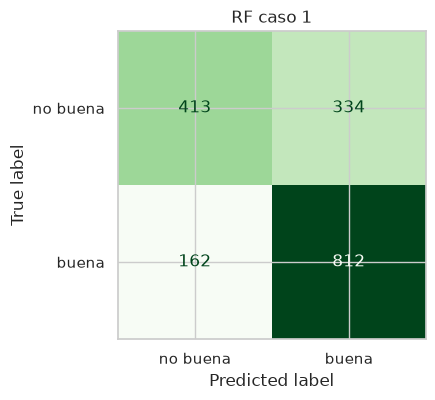

              precision    recall  f1-score   support

    no buena      0.718     0.553     0.625       747
       buena      0.709     0.834     0.766       974

    accuracy                          0.712      1721
   macro avg      0.713     0.693     0.695      1721
weighted avg      0.713     0.712     0.705      1721



In [15]:
# Random Forest con min_samples_leaf escogido por validacion cruzada
hoja_1 = elegir_hoja(cols_1, "buena", "f1")
rf_1, pred_1, met_1 = evaluar(crear_rf(hoja_1), cols_1, "buena", "RF caso 1", ETQ_BIN)

In [16]:
# Comparacion con la regresion logistica del mismo caso
_, _, met_1_log = evaluar(logistica(), cols_1, "buena", "Logistica caso 1", ETQ_BIN, mostrar=False)
tabla_1 = pd.DataFrame([met_1_log, met_1_libre, met_1]).set_index("modelo").round(4)
tabla_1

,n_variables,accuracy_train,accuracy,precision,recall,f1
modelo,,,,,,
Logistica caso 1,1,0.6671,0.6903,0.6971,0.8008,0.7453
RF caso 1 sin limite,1,0.7189,0.6944,0.6989,0.8080,0.7495
RF caso 1,1,0.7081,0.7118,0.7086,0.8337,0.7660


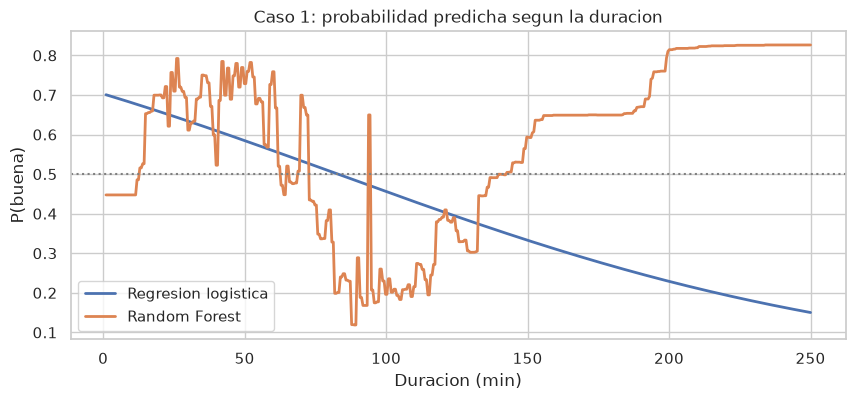

In [17]:
# Probabilidad de ser buena segun la duracion: logistica vs Random Forest
x = pd.DataFrame({"duracion": np.linspace(1, 250, 500)})
log_1 = logistica().fit(train[cols_1], train["buena"])
plt.figure(figsize=(10, 4))
plt.plot(x["duracion"], log_1.predict_proba(x)[:, 1], label="Regresion logistica", lw=2)
plt.plot(x["duracion"], rf_1.predict_proba(x)[:, 1], label="Random Forest", lw=2)
plt.axhline(0.5, color="gray", ls=":")
plt.xlabel("Duracion (min)")
plt.ylabel("P(buena)")
plt.title("Caso 1: probabilidad predicha segun la duracion")
plt.legend()
plt.show()

### Conclusiones del caso 1

Con parámetros por defecto el Random Forest tiene un accuracy de entrenamiento de 0.719 y de prueba de 0.694. La diferencia es pequeña porque con una sola variable, que además tiene pocos valores distintos (minutos enteros), los árboles no tienen mucho que memorizar.

La validación cruzada escogió `min_samples_leaf = 40`, y con eso el modelo llega a un accuracy de **0.712** y un F1 de **0.766**. La regresión logística del mismo caso había sacado 0.690 y 0.745, así que Random Forest le gana usando exactamente la misma información.

La gráfica de probabilidades explica por qué. La regresión logística solo puede dibujar una curva sigmoide que baja suavemente con la duración. El Random Forest aprende una función por escalones: da probabilidades altas entre 15 y 70 minutos (episodios), las baja mucho entre 80 y 120 minutos (la duración típica de una película) y las vuelve a subir por encima de los 150 minutos, donde aparecen miniseries y especiales largos que suelen estar bien calificados. La regresión logística le da a un título de 250 minutos una probabilidad casi nula de ser bueno, mientras que el Random Forest aprendió que esos casos sí tienden a ser buenos. Esos patrones existen en los datos y un modelo lineal no los puede representar.

La debilidad es la misma que en la logística: el modelo reconoce mucho mejor los títulos buenos (recall de 0.834) que los no buenos (recall de 0.553). Con solo la duración, muchas películas bien calificadas y muchos episodios malos no se pueden distinguir.

## 5. Caso 2: Random Forest con varias variables

**Enunciado.** Resolver el mismo caso 2 de la regresión logística pero con Random Forest y obtener las mismas métricas. Después resolverlo con Random Forest usando todas las columnas característica.

Lo hacemos en dos partes:

1. **Parte A:** las mismas dos variables del paso A de regresión logística (`duracion` y `log_votos`).
2. **Parte B:** todas las columnas característica (las 43 del paso D de regresión logística).

F1 promedio en validacion cruzada por min_samples_leaf: {1: 0.658, 5: 0.7158, 10: 0.724, 20: 0.7341, 40: 0.7445} | elegido: 40


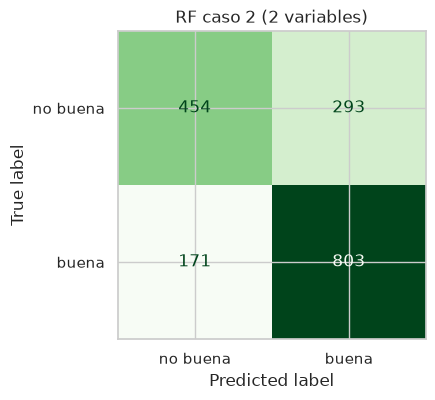

              precision    recall  f1-score   support

    no buena      0.726     0.608     0.662       747
       buena      0.733     0.824     0.776       974

    accuracy                          0.730      1721
   macro avg      0.730     0.716     0.719      1721
weighted avg      0.730     0.730     0.726      1721



In [18]:
# Parte A: duracion + log_votos
cols_2 = ["duracion", "log_votos"]
hoja_2 = elegir_hoja(cols_2, "buena", "f1")
rf_2, pred_2, met_2 = evaluar(crear_rf(hoja_2), cols_2, "buena", "RF caso 2 (2 variables)", ETQ_BIN)

Numero de columnas caracteristica: 43


F1 promedio en validacion cruzada por min_samples_leaf: {1: 0.7747, 5: 0.7905, 10: 0.7901, 20: 0.7836, 40: 0.7779} | elegido: 5


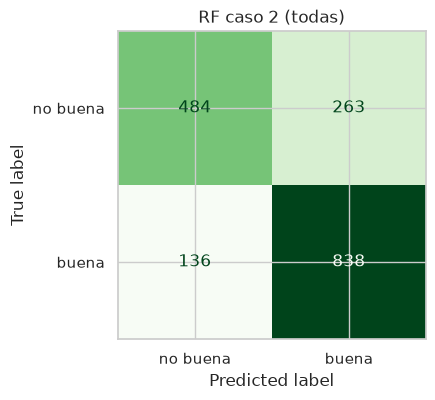

              precision    recall  f1-score   support

    no buena      0.781     0.648     0.708       747
       buena      0.761     0.860     0.808       974

    accuracy                          0.768      1721
   macro avg      0.771     0.754     0.758      1721
weighted avg      0.770     0.768     0.764      1721



In [19]:
# Parte B: todas las columnas caracteristica
vars_estructura = ["es_serie", "es_episodio", "en_emision"]
vars_extra = ["anio_inicio", "tiene_director", "n_actores", "n_generos",
              "largo_sinopsis", "sin_sinopsis", "duracion_faltante"]
todas = ["duracion", "log_votos"] + vars_estructura + vars_extra + cols_generos + cols_tipos
print("Numero de columnas caracteristica:", len(todas))

hoja_todas = elegir_hoja(todas, "buena", "f1")
rf_todas, pred_todas, met_todas = evaluar(crear_rf(hoja_todas), todas, "buena", "RF caso 2 (todas)", ETQ_BIN)

In [20]:
# Comparacion con la regresion logistica usando las mismas variables
_, _, met_2_log = evaluar(logistica(), cols_2, "buena", "Logistica 2 variables", ETQ_BIN, mostrar=False)
_, _, met_todas_log = evaluar(logistica(), todas, "buena", "Logistica todas", ETQ_BIN, mostrar=False)

tabla_2 = pd.DataFrame([met_1_log, met_1, met_2_log, met_2, met_todas_log, met_todas]).set_index("modelo").round(4)
tabla_2

,n_variables,accuracy_train,accuracy,precision,recall,f1
modelo,,,,,,
Logistica caso 1,1,0.6671,0.6903,0.6971,0.8008,0.7453
RF caso 1,1,0.7081,0.7118,0.7086,0.8337,0.7660
Logistica 2 variables,2,0.6532,0.6734,0.6764,0.8111,0.7376
RF caso 2 (2 variables),2,0.7259,0.7304,0.7327,0.8244,0.7758
Logistica todas,43,0.7568,0.7461,0.7594,0.8070,0.7825
RF caso 2 (todas),43,0.8550,0.7682,0.7611,0.8604,0.8077


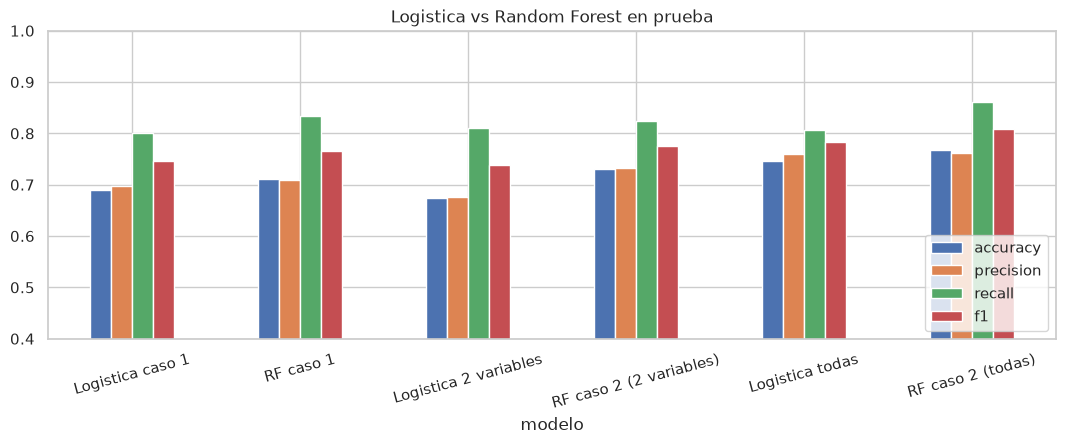

In [21]:
tabla_2[["accuracy", "precision", "recall", "f1"]].plot(kind="bar", figsize=(13, 4), rot=15, ylim=(0.4, 1))
plt.title("Logistica vs Random Forest en prueba")
plt.legend(loc="lower right")
plt.show()

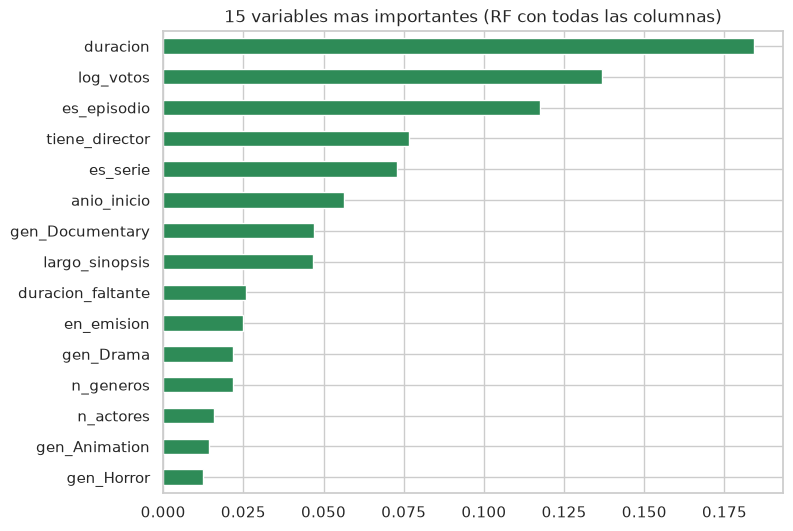

In [22]:
# Importancia de cada variable: cuanto reduce en promedio la impureza de Gini en todos los arboles
imp_todas = pd.Series(rf_todas.feature_importances_, index=todas).sort_values(ascending=False)
imp_todas.head(15).sort_values().plot(kind="barh", figsize=(8, 6), color="seagreen")
plt.title("15 variables mas importantes (RF con todas las columnas)")
plt.show()

### Conclusiones del caso 2

**Parte A (dos variables).** Aquí se ve claramente el sobreajuste. Con árboles sin límite (`min_samples_leaf = 1`) el F1 en validación cruzada es de apenas 0.658, porque con dos variables continuas cada combinación de duración y votos es casi única y los árboles memorizan los títulos. Al exigir 40 filas por hoja el F1 sube a 0.745. Con ese ajuste el modelo llega en prueba a un accuracy de **0.730** y un F1 de **0.776**, contra 0.673 y 0.738 de la regresión logística con las mismas dos variables.

Es la mayor diferencia entre los dos modelos y tiene una explicación directa. En regresión logística agregar `log_votos` empeoró el modelo porque la relación de los votos con el rating no es monótona. Random Forest sí aprovecha esa variable y mejora respecto a su propio caso 1 (0.712 a 0.730 en accuracy).

**Parte B (todas las columnas).** Con las 43 columnas el Random Forest llega a un accuracy de **0.768** y un F1 de **0.808** (precision 0.761, recall 0.860), el mejor resultado de todo el informe para el problema binario. La regresión logística con las mismas columnas sacó 0.746 y 0.783. En la matriz de confusión también mejora la clase no buena: reconoce 484 de 747 títulos, contra 408 del caso 1.

Hay algo de sobreajuste: el accuracy de entrenamiento es 0.855 y el de prueba 0.768. Aun así es la configuración que mejor le fue en validación cruzada, y en prueba supera a todas las demás. En Random Forest es normal que entrenamiento quede por encima, porque cada árbol vio buena parte de esas filas.

Las variables más importantes son `duracion`, `log_votos`, `es_episodio`, `tiene_director` y `es_serie`. Coinciden con lo que encontramos en el análisis exploratorio y en los coeficientes de la regresión logística. Hay que leer esta importancia con cuidado: la importancia de Gini favorece a las variables numéricas con muchos valores distintos. Por eso `largo_sinopsis` aparece arriba aunque en el análisis exploratorio no separaba las clases.

## 6. Caso 3: Random Forest multiclase

**Enunciado.** Seleccionar todas las columnas característica y una variable objetivo de clasificación multiclase, obtener métricas de desempeño (matriz de confusión, accuracy, f1 score, precision, recall), remover las columnas característica que sean necesarias para mejorar las métricas y sacar conclusiones.

**Variable objetivo:** `categoria` (Baja, Media, Alta). **Variables características:** las 43 columnas.

Random Forest maneja varias clases de forma natural: cada hoja guarda la proporción de cada clase y el bosque vota por la más probable. No hace falta entrenar un modelo por clase como en otros métodos.

F1 promedio en validacion cruzada por min_samples_leaf: {1: 0.5846, 5: 0.586, 10: 0.5705, 20: 0.5524, 40: 0.5439} | elegido: 5


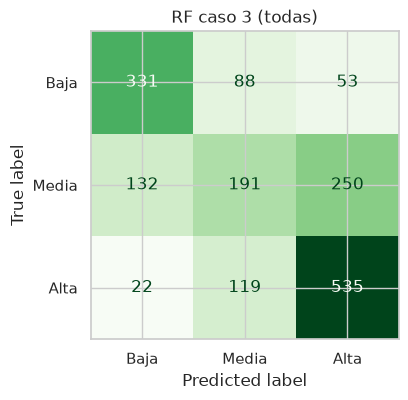

              precision    recall  f1-score   support

        Baja      0.682     0.701     0.692       472
       Media      0.480     0.333     0.393       573
        Alta      0.638     0.791     0.707       676

    accuracy                          0.614      1721
   macro avg      0.600     0.609     0.597      1721
weighted avg      0.598     0.614     0.598      1721



,modelo,n_variables,accuracy_train,accuracy,precision,recall,f1
0,RF caso 3 (todas),43,0.7754,0.6142,0.6003,0.6087,0.5973


In [23]:
hoja_3 = elegir_hoja(todas, "categoria", "f1_macro")
rf_3, pred_3, met_3 = evaluar(crear_rf(hoja_3), todas, "categoria", "RF caso 3 (todas)", ETQ_MULTI)
pd.DataFrame([met_3]).round(4)

### Eliminación de columnas

Probamos dos formas de escoger qué columnas quitar:

1. **Por importancia de Gini:** el propio Random Forest calcula cuánto reduce cada columna la impureza de Gini en todos los árboles. Probamos varios umbrales y en cada uno quitamos las columnas con importancia menor al umbral.
2. **Por lo visto en el análisis exploratorio:** `n_actores` tiene IQR igual a cero (casi todos los títulos tienen 4 actores), `sin_sinopsis` no cambia el porcentaje de títulos buenos (54.7 % contra 54.9 %) y `largo_sinopsis` tiene la misma mediana en todas las clases. En teoría no aportan información, y lo que pueden hacer es meter ruido. Esto es importante porque la importancia de Gini tiende a sobrevalorar las columnas numéricas con muchos valores distintos, como `largo_sinopsis`, aunque no sirvan para predecir.

Cada conjunto de columnas se evalúa con validación cruzada dentro del entrenamiento, y el conjunto de prueba solo se usa al final con la opción ganadora. Si escogiéramos las columnas mirando el conjunto de prueba, la métrica final quedaría inflada.

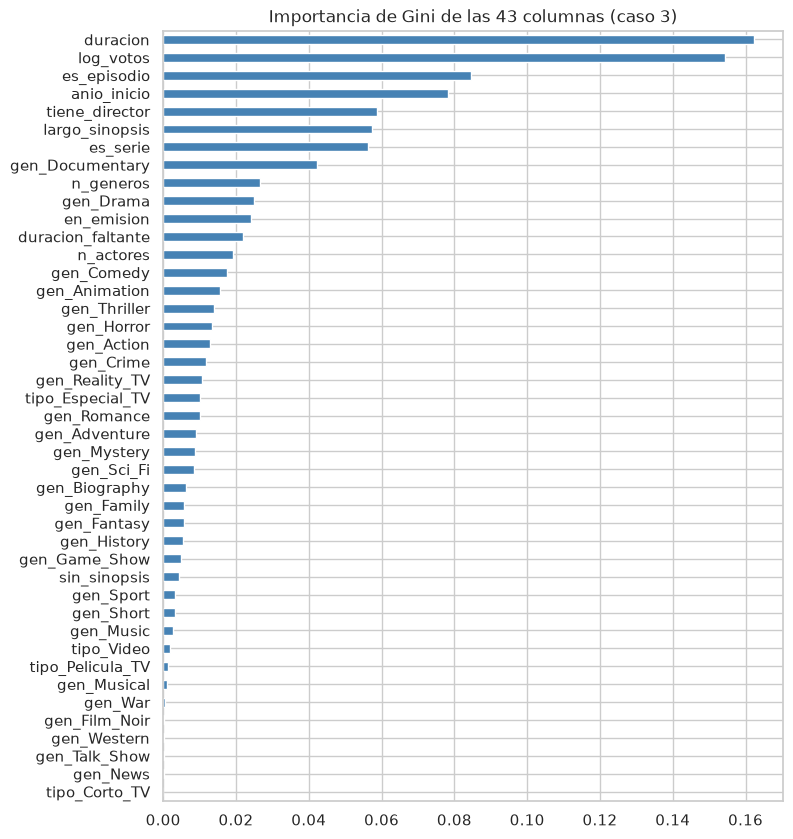

In [24]:
# Importancias del modelo multiclase con todas las columnas
imp_3 = pd.Series(rf_3.feature_importances_, index=todas).sort_values()
fig, eje = plt.subplots(figsize=(8, 10))
imp_3.plot(kind="barh", ax=eje, color="steelblue")
eje.set_title("Importancia de Gini de las 43 columnas (caso 3)")
plt.show()

In [25]:
# Conjuntos candidatos de columnas
sin_info = ["n_actores", "sin_sinopsis", "largo_sinopsis"]
candidatos = {"Todas": todas}
for u in [0.002, 0.005, 0.01, 0.02]:
    candidatos[f"Gini >= {u}"] = [c for c in todas if imp_3[c] >= u]
candidatos["Sin columnas sin informacion (EDA)"] = [c for c in todas if c not in sin_info]
candidatos["Gini >= 0.005 y sin columnas EDA"] = [c for c in todas if imp_3[c] >= 0.005 and c not in sin_info]

# F1 macro promedio en validacion cruzada agrupada, solo con el entrenamiento
filas = []
for nombre, cols in candidatos.items():
    f1_cv = cross_val_score(crear_rf(hoja_3), train[cols], train["categoria"],
                            groups=grupos_train, cv=cv, scoring="f1_macro").mean()
    filas.append({"conjunto": nombre, "n_columnas": len(cols), "f1_macro_cv": f1_cv})

tabla_cand = pd.DataFrame(filas).set_index("conjunto")
tabla_cand.round(4)

,n_columnas,f1_macro_cv
conjunto,,
Todas,43,0.5860
Gini >= 0.002,34,0.5825
Gini >= 0.005,29,0.5914
Gini >= 0.01,22,0.5808
Gini >= 0.02,12,0.5796
Sin columnas sin informacion (EDA),40,0.5893
Gini >= 0.005 y sin columnas EDA,27,0.5923


Conjunto elegido: Gini >= 0.005 y sin columnas EDA (27 columnas)
Columnas eliminadas: ['gen_Film_Noir', 'gen_Game_Show', 'gen_Music', 'gen_Musical', 'gen_News', 'gen_Short', 'gen_Sport', 'gen_Talk_Show', 'gen_War', 'gen_Western', 'largo_sinopsis', 'n_actores', 'sin_sinopsis', 'tipo_Corto_TV', 'tipo_Pelicula_TV', 'tipo_Video']


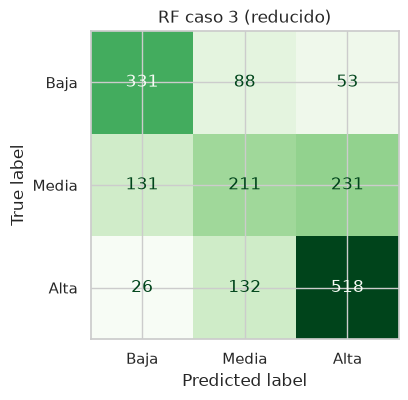

              precision    recall  f1-score   support

        Baja      0.678     0.701     0.690       472
       Media      0.490     0.368     0.420       573
        Alta      0.646     0.766     0.701       676

    accuracy                          0.616      1721
   macro avg      0.605     0.612     0.604      1721
weighted avg      0.603     0.616     0.604      1721



In [26]:
# Nos quedamos con el conjunto de mejor F1 en validacion y lo evaluamos una sola vez en prueba
nombre_mejor = tabla_cand["f1_macro_cv"].idxmax()
cols_final = candidatos[nombre_mejor]
print(f"Conjunto elegido: {nombre_mejor} ({len(cols_final)} columnas)")
print("Columnas eliminadas:", sorted(set(todas) - set(cols_final)))

rf_3b, pred_3b, met_3b = evaluar(crear_rf(hoja_3), cols_final, "categoria", "RF caso 3 (reducido)", ETQ_MULTI)

In [27]:
tabla_3 = pd.DataFrame([met_3, met_3b]).set_index("modelo").round(4)
tabla_3

,n_variables,accuracy_train,accuracy,precision,recall,f1
modelo,,,,,,
RF caso 3 (todas),43,0.7754,0.6142,0.6003,0.6087,0.5973
RF caso 3 (reducido),27,0.7765,0.6159,0.6046,0.6119,0.6036


### Conclusiones del caso 3

Con todas las columnas el modelo multiclase llega a un accuracy de **0.614** y un F1 macro de **0.597**, muy por encima del 0.366 de predecir siempre la clase más frecuente. Es más bajo que en el problema binario, lo cual es normal: con tres clases hay más formas de equivocarse, y ahora los límites entre clases están a solo un punto de rating.

El reporte por clase muestra dónde está el problema. Baja (F1 0.692) y Alta (F1 0.707) se predicen razonablemente bien, pero **Media** tiene un F1 de apenas 0.393 y un recall de 0.333. Está en el medio: un título de 6.6 se parece mucho a uno de 6.4 (baja) y uno de 7.4 se parece mucho a uno de 7.6 (alta), así que el modelo la confunde hacia ambos lados. En la matriz de confusión hay pocos errores directos entre Baja y Alta (75 de 1721 títulos). Los errores se concentran en la frontera con Media, y de los títulos medios la mayoría de los mal clasificados se van hacia Alta (250) más que hacia Baja (132).

**Eliminación de columnas.** En validación cruzada, quitar columnas poco importantes mejora un poco el F1 hasta cierto punto. Con el umbral de Gini de 0.005 se eliminan 14 columnas y el F1 de validación sube de 0.586 a 0.591. Si se quitan demasiadas (umbral de 0.02, solo 12 columnas) el modelo empeora, porque se pierde información útil. La mejor opción fue combinar el umbral de 0.005 con quitar las tres columnas que el análisis exploratorio señaló como sin información. Así quedan 27 columnas: salen 10 géneros poco frecuentes (noticias, western, guerra, cine negro, etc.), 3 tipos con muy pocos títulos y `n_actores`, `sin_sinopsis` y `largo_sinopsis`.

Evaluado una sola vez en prueba, el modelo reducido pasa de 0.597 a **0.604** de F1 macro y de 0.614 a **0.616** de accuracy. La clase Media es la que más mejora (F1 de 0.393 a 0.420). La mejora es pequeña, pero el modelo usa 16 columnas menos y rinde igual o un poco mejor, lo que confirma que esas columnas solo metían ruido. Para mejorar de verdad la clase media harían falta variables que este dataset no tiene.

## 7. Conclusiones generales

1. Random Forest superó a la regresión logística en todos los casos comparables. Con una variable: F1 de 0.766 contra 0.745. Con dos variables: 0.776 contra 0.738. Con todas: 0.808 contra 0.783. La mayor ventaja aparece cuando hay relaciones no lineales, como la de los votos con el rating.
2. Random Forest también necesita cuidado con el sobreajuste. Con pocas variables continuas y árboles sin límite, el modelo memoriza el entrenamiento. Controlar `min_samples_leaf` con validación cruzada fue lo que hizo que funcionara.
3. Las variables más útiles en los tres notebooks fueron las mismas: duración, votos, si es serie o episodio, si tiene director y el género. Todas salieron de la limpieza del texto original, así que buena parte del resultado depende de la limpieza y la transformación, como se pedía en el taller.
4. El problema multiclase es bastante más difícil que el binario, sobre todo para la clase del medio. Quitar columnas con poca importancia o sin información dejó un modelo más simple con un rendimiento un poco mejor.
5. Separar entrenamiento y prueba por título fue clave para no engañarnos. Con una división aleatoria normal, las métricas salen varios puntos más altas porque el modelo ve episodios de la misma serie en los dos conjuntos.